### Importação das bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# carregando o dataset
df = pd.read_csv("mtcars.csv")

# visualizar as primeiras linhas 
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


## Questão 1 — Estatísticas descritivas

In [17]:
# variável escolhida
variable = "hp"

# agrupando por transmissão
group = df.groupby("am")[variable]

# tabela de estatísticas
tabela = pd.DataFrame({

    'N. Obs.': group.count(),
    'Média': group.mean(),
    'Desvio Padrão': group.std(),
    'Mediana': group.median(),
    'IQR': group.quantile(0.75) - group.quantile(0.25)

})

tabela

,N. Obs.,Média,Desvio Padrão,Mediana,IQR
am,,,,,
0,19,160.263158,53.908196,175.0,76.0
1,13,126.846154,84.062324,109.0,47.0


## Questão 2 — Histograma

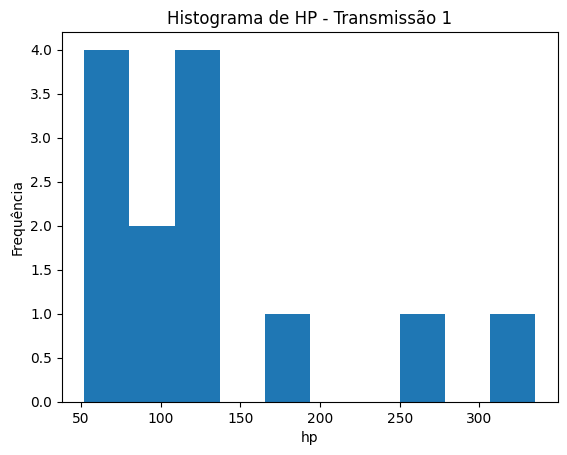

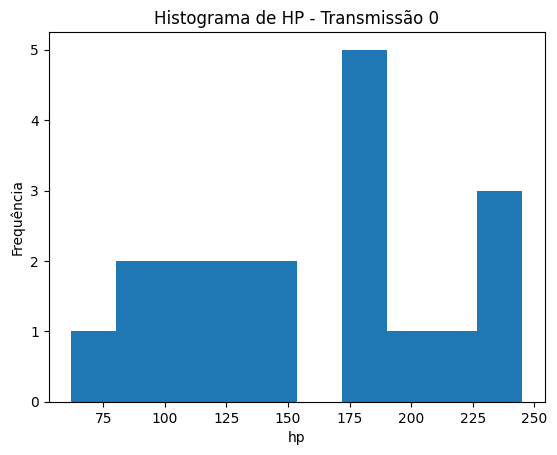

In [18]:
# histogramas de transmissão 1 e 0

for transmission in df['am'].unique():

    data = df[df['am'] == transmission]['hp']

    plt.hist(data)

    plt.title(f'Histograma de HP - Transmissão {transmission}')
    plt.xlabel("hp")
    plt.ylabel("Frequência")

    plt.show()

## Questão 3 — Boxplot

/tmp/ipykernel_65613/3359168930.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=["4 cilindros", "6 cilindros", "8 cilindros"])


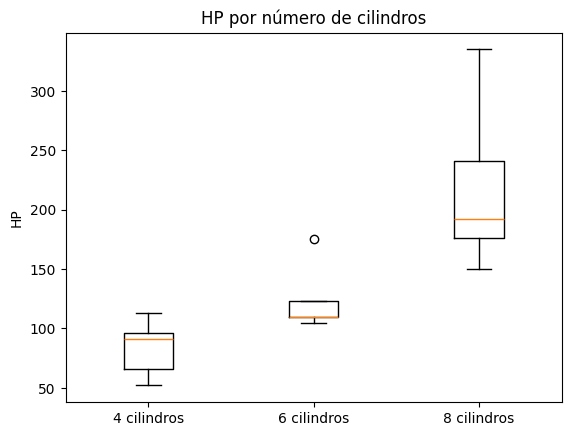

In [19]:
# boxplot comparando hp entre cilindros

data = [
    df[df['cyl'] == 4]['hp'],
    df[df['cyl'] == 6]['hp'],
    df[df['cyl'] == 8]['hp']
]

plt.boxplot(data, labels=["4 cilindros", "6 cilindros", "8 cilindros"])

plt.title("HP por número de cilindros")
plt.ylabel("HP")

plt.show()

## Questão 4 — Scatter plot

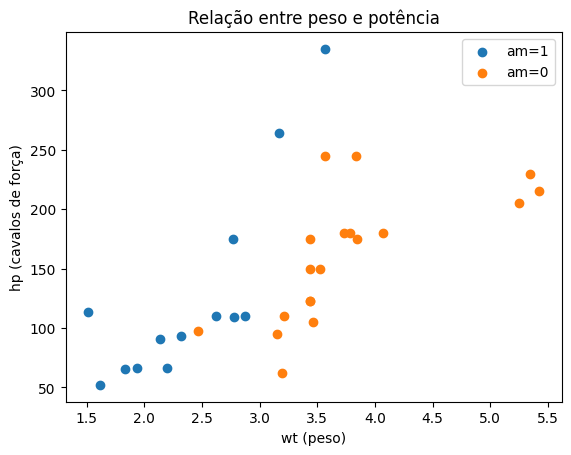

In [20]:
# percorre cada tipo de transmissão presente no dataset
for transmission in df['am'].unique():

    # filtra apenas os dados do grupo atual
    data = df[df['am'] == transmission]

    # cria o gráfico de dispersão entre peso e consumo
    plt.scatter(data['wt'], data['hp'], label=f"am={transmission}")


# define o nome do eixo x
plt.xlabel("wt (peso)")

# define o nome do eixo y
plt.ylabel("hp (cavalos de força)")

# título do gráfico
plt.title("Relação entre peso e potência")

# adiciona a legenda com os tipos de transmissão
plt.legend()

# exibe o gráfico
plt.show()

## Questão 5 — Qui-Quadrado (cyl x gear)

In [21]:
# cria a tabela de contingência entre número de cilindros e marchas
contingency = pd.crosstab(df['cyl'], df['gear'])

# exibe a tabela
contingency

gear,3,4,5
cyl,,,
4,1,8,2
6,2,4,1
8,12,0,2


In [10]:
# executa o teste de independência Qui-Quadrado
chi2, p, dof, expected = stats.chi2_contingency(contingency)

# exibe o valor da estatística Qui-Quadrado
print("Qui-quadrado:", chi2)

# exibe o p-valor do teste
print("p-valor:", p)

Qui-quadrado: 18.03636363636364
p-valor: 0.0012140660337851554


## Questão 6 — Barras empilhadas

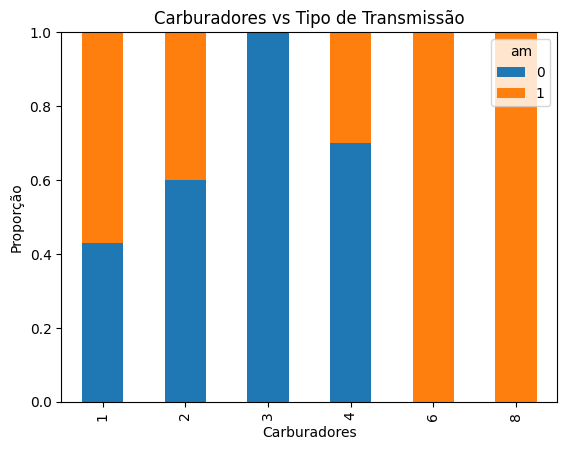

In [11]:
# cria uma tabela cruzada entre carburadores e transmissão
table = pd.crosstab(df['carb'], df['am'], normalize='index')

# gera o gráfico de barras empilhadas
table.plot(kind="bar", stacked=True)

# define o título do gráfico
plt.title("Carburadores vs Tipo de Transmissão")

# nome do eixo x
plt.xlabel("Carburadores")

# nome do eixo y
plt.ylabel("Proporção")

# mostra o gráfico
plt.show()

In [12]:
# cria a tabela de contingência entre carburadores e transmissão
contingency = pd.crosstab(df['carb'], df['am'])

# executa o teste Qui-Quadrado
chi2, p, dof, expected = stats.chi2_contingency(contingency)

# exibe os resultados
print("Qui-quadrado:", chi2)
print("p-valor:", p)

Qui-quadrado: 6.237131289762869
p-valor: 0.28382408908880563


## Questão 7 — Teste final

In [13]:
# cria a tabela de contingência entre transmissão e número de cilindros
table = pd.crosstab(df['am'], df['cyl'])

# executa o teste Qui-Quadrado
chi2, p, dof, expected = stats.chi2_contingency(table)

# mostra o valor do Qui-Quadrado
print("Qui-quadrado:", chi2)

# mostra o p-valor
print("p-valor:", p)

Qui-quadrado: 8.740732951259268
p-valor: 0.012646605046107276
